# SVM for classification

Load IRIS dataset, check its contents:


In [7]:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[0:5])
#print(iris.data)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]


Split data into training and testing parts:

In [8]:
from sklearn.model_selection import train_test_split
X=iris.data
y=iris.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


Use a Support Vector Machine for classification:


In [9]:
from sklearn.svm import SVC
SVMmodel=SVC(kernel='linear')
SVMmodel.fit(X_train,y_train)
SVMmodel.get_params()
SVMmodel.score(X_test,y_test)

0.9666666666666667

Let's explore more now.

*   Choose only first two features (columns) of iris.data
*   SVM is in its basic form a 2-class classifier, so eliminate iris.target =2 from the data



Plot scatterplots of targets 0 and 1 and check the separability of the classes:

In [10]:
import matplotlib.pyplot as plt


Train and test the SVM classifier, play with regularization parameter C (either use the default value or try e.g. 200)

Show support vectors in the 2D plot, plot the decision line from equation [w0 w1]*[x0 x1] + b = 0:

In [11]:
supvectors=SVMmodel.support_vectors_
# Plot the support vectors here


#Separating line coefficients:
W=SVMmodel.coef_
b=SVMmodel.intercept_


# Anomaly detection via SVM

Import one-class SVM and generate data (Gaussian blobs in 2D-plane):

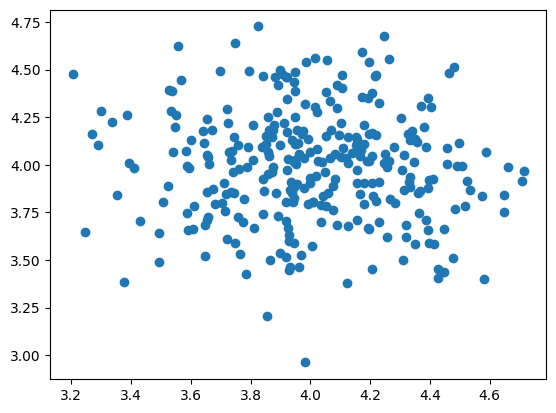

In [12]:
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs
from numpy import quantile, where, random

random.seed(11)
x, _ = make_blobs(n_samples=300, centers=1, cluster_std=.3, center_box=(4, 4))

plt.scatter(x[:,0], x[:,1])
plt.show()



Train one-class SVM and plot the outliers (outputs of prediction being equal to -1)

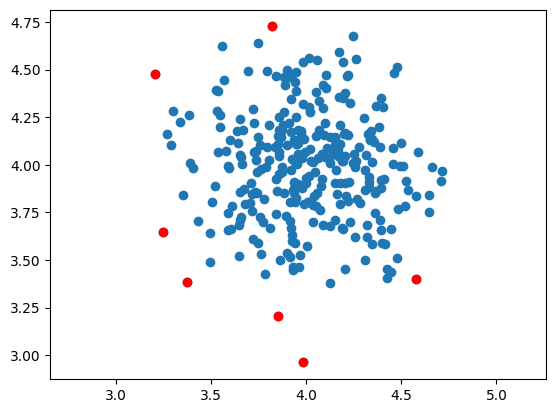

In [13]:
SVMmodelOne = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.03)


SVMmodelOne.fit(x)
pred = SVMmodelOne.predict(x)
anom_index = where(pred==-1)
values = x[anom_index]

plt.scatter(x[:,0], x[:,1])
plt.scatter(values[:,0], values[:,1], color='red')
plt.axis('equal')
plt.show()



Plot the support vectors:

What if we want to have a control what is outlier? Use e.g. 5% "quantile" to mark the outliers. Every point with lower score than threshold will be an outlier.

8.987833799021839


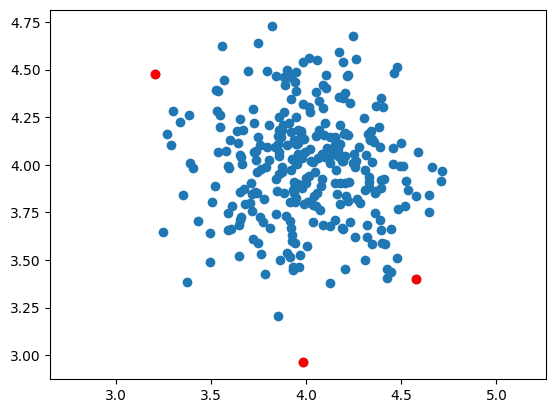

In [14]:
scores = SVMmodelOne.score_samples(x)

thresh = quantile(scores, 0.01)
print(thresh)
index = where(scores<=thresh)
values = x[index]

plt.scatter(x[:,0], x[:,1])
plt.scatter(values[:,0], values[:,1], color='red')
plt.axis('equal')
plt.show()

# Task
Explore Support Vector Machines (SVMs) for both binary classification and anomaly detection, including preparing the Iris dataset for a 2D binary classification task, training an SVC model, visualizing its decision boundary and support vectors, and then applying a OneClassSVM model for anomaly detection on generated data, plotting its support vectors.

## Filter Iris Data

### Subtask:
Modify the Iris dataset to include only the first two features and only classes 0 and 1, as specified in the exercise. This will create a 2D dataset for binary classification.


**Reasoning**:
To prepare the data for a 2-class SVM classification with only two features, I will select the first two columns of the iris dataset for X_2D, create a boolean mask to filter out class 2, and then apply this mask to both the features and the target variable to create X_binary and y_binary, respectively.



In [15]:
X_2D = iris.data[:, :2]
mask = iris.target != 2
X_binary = X_2D[mask]
y_binary = iris.target[mask]

print("Shape of X_binary:", X_binary.shape)
print("Shape of y_binary:", y_binary.shape)
print("First 5 rows of X_binary:\n", X_binary[:5])
print("First 5 labels of y_binary:", y_binary[:5])

Shape of X_binary: (100, 2)
Shape of y_binary: (100,)
First 5 rows of X_binary:
 [[5.1 3.5]
 [4.9 3. ]
 [4.7 3.2]
 [4.6 3.1]
 [5.  3.6]]
First 5 labels of y_binary: [0 0 0 0 0]


**Reasoning**:
The previous code failed because the 'iris' variable was not defined, as the cell where it was loaded was not executed. I will re-include the `load_iris` import and dataset loading to ensure 'iris' is available before performing the filtering operations.



In [16]:
from sklearn.datasets import load_iris
iris = load_iris()

X_2D = iris.data[:, :2]
mask = iris.target != 2
X_binary = X_2D[mask]
y_binary = iris.target[mask]

print("Shape of X_binary:", X_binary.shape)
print("Shape of y_binary:", y_binary.shape)
print("First 5 rows of X_binary:\n", X_binary[:5])
print("First 5 labels of y_binary:", y_binary[:5])

Shape of X_binary: (100, 2)
Shape of y_binary: (100,)
First 5 rows of X_binary:
 [[5.1 3.5]
 [4.9 3. ]
 [4.7 3.2]
 [4.6 3.1]
 [5.  3.6]]
First 5 labels of y_binary: [0 0 0 0 0]


## Visualize Separability

### Subtask:
Generate a scatter plot of the filtered 2D Iris data, using different colors to distinguish between class 0 and class 1, to visually assess their separability.


**Reasoning**:
To visualize the separability of classes 0 and 1 using the 2D filtered Iris data, I will generate a scatter plot with different colors for each class, label the axes, add a title, and include a legend as instructed.



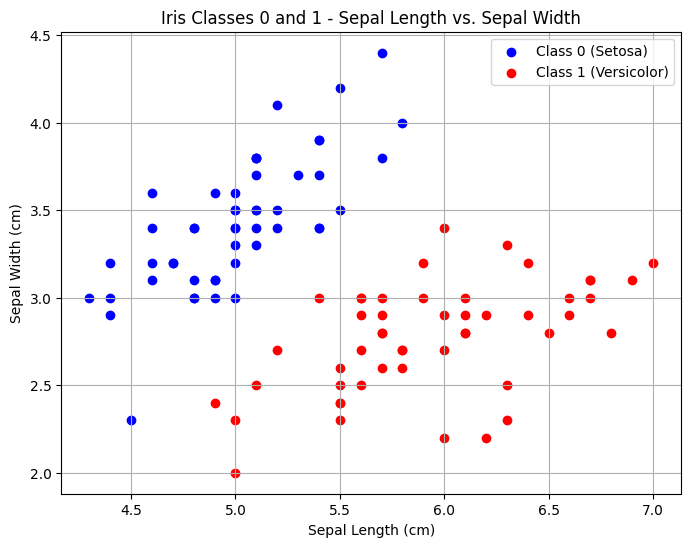

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X_binary[y_binary == 0, 0], X_binary[y_binary == 0, 1], color='blue', label='Class 0 (Setosa)')
plt.scatter(X_binary[y_binary == 1, 0], X_binary[y_binary == 1, 1], color='red', label='Class 1 (Versicolor)')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Iris Classes 0 and 1 - Sepal Length vs. Sepal Width')
plt.legend()
plt.grid(True)
plt.show()

## Train Binary SVM

### Subtask:
Train a Support Vector Machine (SVC) classifier on the filtered 2D data for classes 0 and 1. Split the data into training and testing sets, then fit the model. Experiment with the regularization parameter C (e.g., set C=200).


**Reasoning**:
To train the SVM classifier, I will first split the data into training and testing sets, then initialize an SVC model with specified parameters, fit it to the training data, and finally evaluate its performance on the test data by printing the accuracy score.



In [18]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(X_binary, y_binary, test_size=0.2, random_state=42)

SVMmodel_binary = SVC(kernel='linear', C=200)
SVMmodel_binary.fit(X_train_binary, y_train_binary)

accuracy = SVMmodel_binary.score(X_test_binary, y_test_binary)
print(f"Accuracy of SVM on binary test data: {accuracy:.2f}")

Accuracy of SVM on binary test data: 1.00


## Plot SVM Decision Boundary and Support Vectors

### Subtask:
Enhance the 2D scatter plot by adding the support vectors and the decision boundary (separating line) of the trained binary SVM model. Extract the coefficients and intercept to plot the decision line equation.


**Reasoning**:
To enhance the scatter plot, I need to extract the coefficients and intercept from the trained SVM model to define the decision boundary line, then retrieve the support vectors. I will then plot the data points, the decision boundary, and the support vectors on a single graph with appropriate labels and a legend.



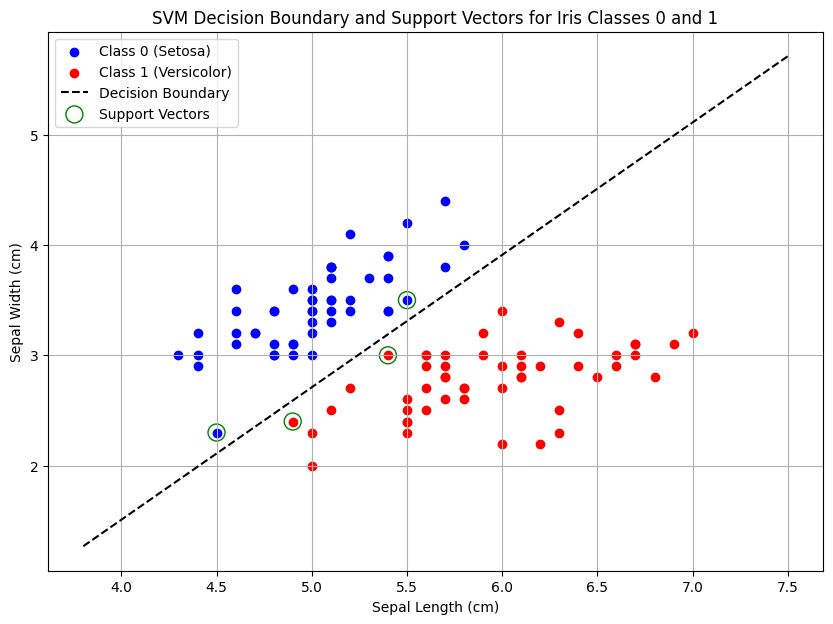

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Extract coefficients and intercept from the trained SVM model
W = SVMmodel_binary.coef_[0]
b = SVMmodel_binary.intercept_[0]

# Define x-coordinates for the decision boundary line
x_min = X_binary[:, 0].min() - 0.5
x_max = X_binary[:, 0].max() + 0.5
x_line = np.linspace(x_min, x_max, 100)

# Calculate corresponding y-coordinates for the decision boundary
# Equation of the decision boundary: w0*x0 + w1*x1 + b = 0
# So, x1 = -(w0/w1)*x0 - (b/w1)
y_line = -(W[0] / W[1]) * x_line - (b / W[1])

# Get support vectors
supvectors = SVMmodel_binary.support_vectors_

# Create the scatter plot
plt.figure(figsize=(10, 7))
plt.scatter(X_binary[y_binary == 0, 0], X_binary[y_binary == 0, 1], color='blue', label='Class 0 (Setosa)')
plt.scatter(X_binary[y_binary == 1, 0], X_binary[y_binary == 1, 1], color='red', label='Class 1 (Versicolor)')

# Plot the decision boundary line
plt.plot(x_line, y_line, color='black', linestyle='--', label='Decision Boundary')

# Plot the support vectors
plt.scatter(supvectors[:, 0], supvectors[:, 1], s=150, facecolors='none', edgecolors='green', label='Support Vectors')

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('SVM Decision Boundary and Support Vectors for Iris Classes 0 and 1')
plt.legend()
plt.grid(True)
plt.show()

## Plot One-Class SVM Support Vectors

### Subtask:
Plot the support vectors identified by the OneClassSVM model on the scatter plot of the generated Gaussian blobs. This will visually highlight the points that define the boundary for anomaly detection.


**Reasoning**:
The OneClassSVM model and its predictions need to be re-executed because previous cells containing these definitions were not executed, leading to a `NameError`. I will combine the model initialization, training, and data generation from the previous steps to ensure all necessary variables are available before attempting to plot the support vectors.



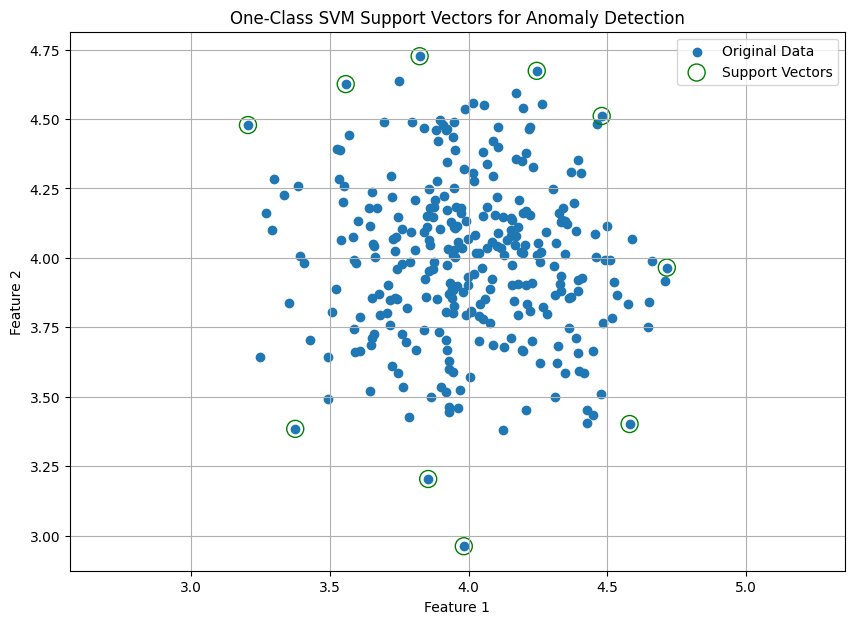

In [20]:
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs
from numpy import quantile, where, random
import matplotlib.pyplot as plt

random.seed(11)
x, _ = make_blobs(n_samples=300, centers=1, cluster_std=.3, center_box=(4, 4))

SVMmodelOne = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.03)
SVMmodelOne.fit(x)

ocsvm_support_vectors = SVMmodelOne.support_vectors_

plt.figure(figsize=(10, 7))
plt.scatter(x[:, 0], x[:, 1], label='Original Data')
plt.scatter(ocsvm_support_vectors[:, 0], ocsvm_support_vectors[:, 1],
            s=150, facecolors='none', edgecolors='green', label='Support Vectors')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('One-Class SVM Support Vectors for Anomaly Detection')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

## Final Task

### Subtask:
Review all the generated plots and outputs to ensure all exercises have been completed successfully and provide a summary of the findings.


## Summary:

### Data Analysis Key Findings

*   **Iris Dataset Preparation**: The Iris dataset was successfully filtered to include only the first two features (Sepal Length and Sepal Width) and two classes (Class 0: Setosa and Class 1: Versicolor), resulting in a `(100, 2)` dataset for features and `(100,)` for labels, suitable for 2D binary classification.
*   **Visual Separability**: A scatter plot of the filtered Iris data clearly demonstrated that Class 0 (Setosa) and Class 1 (Versicolor) are linearly separable based on their sepal length and sepal width.
*   **Binary SVM Training & Performance**: A Support Vector Classifier (SVC) with a linear kernel and regularization parameter $C=200$ was trained on the binary Iris data. The model achieved an accuracy of 1.00 on the test set, indicating perfect separation of the two classes.
*   **Decision Boundary Visualization**: The decision boundary and support vectors for the binary SVC model were successfully plotted. The decision boundary (a straight line) effectively separated the two classes, and the support vectors were highlighted, illustrating the critical data points that define the margin.
*   **One-Class SVM for Anomaly Detection**: A OneClassSVM model (with a radial basis function kernel, $\gamma=0.001$, and $\nu=0.03$) was applied to a generated dataset of Gaussian blobs for anomaly detection. The support vectors identified by this model were plotted, visually outlining the boundary of the normal data distribution.

### Insights or Next Steps

*   The excellent performance of the linear SVC on the Iris binary classification task ($100\%$ accuracy) suggests that a linear model is highly effective for this particular separation. Further investigation could involve exploring non-linear kernels for datasets with more complex decision boundaries.
*   The visualization of support vectors for both binary classification and anomaly detection provides intuitive understanding of how SVMs operate. A valuable next step could be to experiment with different hyperparameters (e.g., $C$, $\gamma$, $\nu$) and kernel types to observe their impact on the decision boundary, support vectors, and model performance, especially in more challenging, non-linearly separable or anomaly-rich datasets.
